In [3]:
!which python

/home/user/jfayzullaev/stellar-clustering/.venv-vis/bin/python


In [4]:
import pandas as pd
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np


In [5]:
LBL_NORM = "~/stellar-clustering/network/labled-data/labels/label-normalization/labels_entities_normalized.csv"

## Transaction

silhouette, Davies–Bouldin, and Calinski–Harabasz

In [6]:
intr = pd.read_csv("transaction_kmeans_intrinsic_scores.csv").sort_values("k")

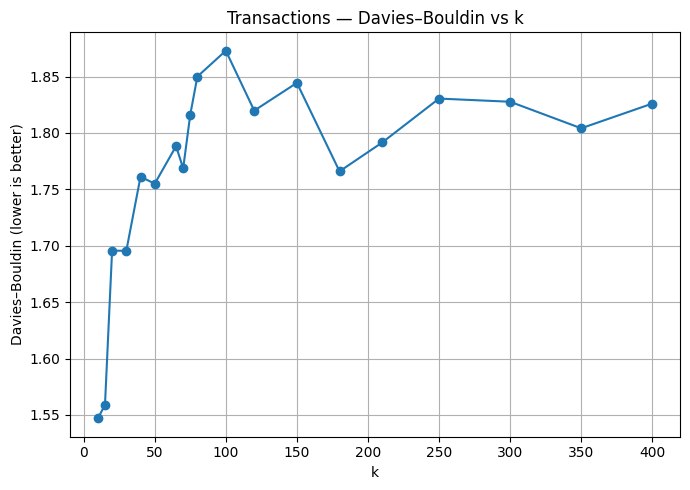

In [7]:
# Davies–Bouldin
plt.figure(figsize=(7,5))
plt.plot(intr["k"], intr["davies_bouldin"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies–Bouldin (lower is better)")
plt.title("Transactions — Davies–Bouldin vs k")
plt.grid(True, which="both", axis="both")
plt.tight_layout(); plt.show()

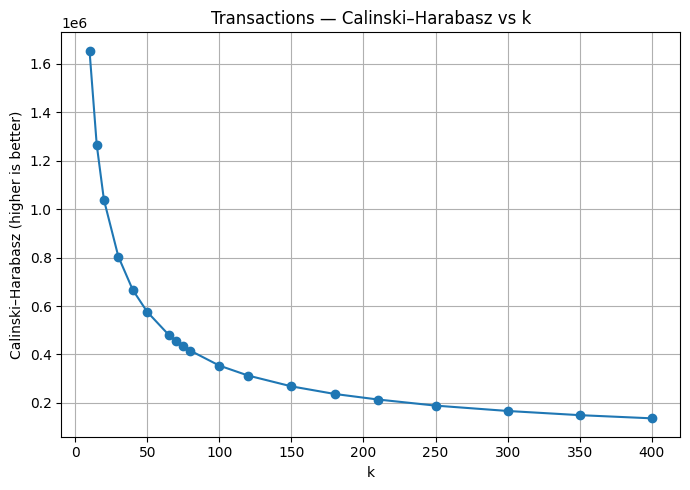

In [8]:
plt.figure(figsize=(7,5))
plt.plot(intr["k"], intr["calinski_harabasz"], marker="o")
plt.xlabel("k"); plt.ylabel("Calinski–Harabasz (higher is better)")
plt.title("Transactions — Calinski–Harabasz vs k")
plt.grid(True, which="both", axis="both")
plt.tight_layout(); plt.show()

### Extr

In [9]:
extr = pd.read_csv("transaction_kmeans_extrinsic_scores.csv").sort_values("k")

In [10]:

display(extr)

,k,NMI_vs_LBL_NORM,ARI_vs_LBL_NORM,Purity_vs_LBL_NORM
0,10,0.078796,0.011277,0.935221
1,15,0.073995,0.009287,0.935221
2,20,0.072859,0.004857,0.935341
3,30,0.074020,0.004536,0.935581
4,40,0.078369,0.004753,0.936060
5,50,0.076819,0.002467,0.936180
6,65,0.080737,0.003206,0.936060
7,70,0.081274,0.002871,0.936780
8,75,0.079992,0.002872,0.936420
9,80,0.079158,0.002398,0.936540


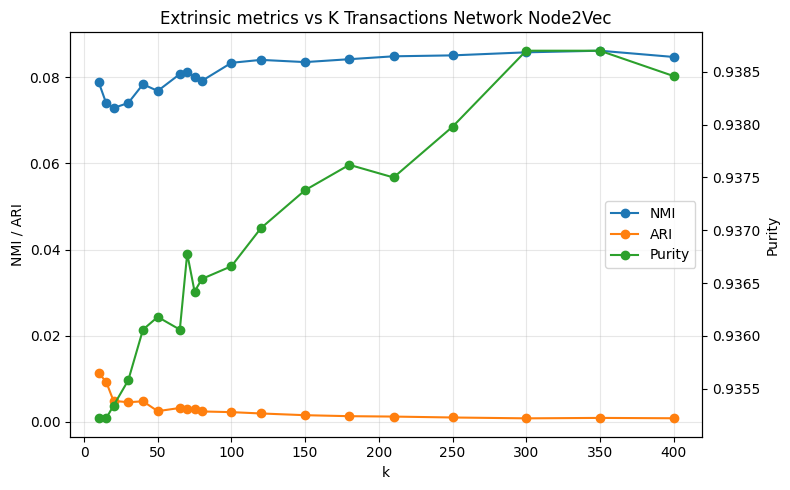

In [11]:
k   = extr["k"].astype(int)
nmi = extr["NMI_vs_LBL_NORM"]
ari = extr["ARI_vs_LBL_NORM"]
pur = extr["Purity_vs_LBL_NORM"]

fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

l1, = ax1.plot(k, nmi, marker="o", label="NMI", color="tab:blue")
l2, = ax1.plot(k, ari, marker="o", label="ARI", color="tab:orange")
l3, = ax2.plot(k, pur, marker="o", label="Purity", color="tab:green")

ax1.set_xlabel("k")
ax1.set_ylabel("NMI / ARI")
ax2.set_ylabel("Purity")

ax1.grid(True, alpha=0.3)
ax1.legend([l1, l2, l3], ["NMI", "ARI", "Purity"], loc="best")
plt.title("Extrinsic metrics vs K Transactions Network Node2Vec")
plt.tight_layout()
plt.show()

all optimal at k=10 15